# 06 - Model Interpretation & Explainable AI

## Objectives
- Explain model predictions using SHAP values
- Visualize feature importance and decision paths
- Understand HOW and WHY models make predictions
- Generate actionable insights for stakeholders

**Models Interpreted**: Logistic Regression, Random Forest, XGBoost

**Techniques**: SHAP, Feature Importance, Decision Tree Visualization, Partial Dependence

## 1. Setup and Imports

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import joblib
from pathlib import Path

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import roc_auc_score

# XGBoost
from xgboost import XGBClassifier, plot_importance

# SHAP
import shap



In [181]:
sys.path.append('..')

Display settings

In [182]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

Visualization

In [183]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## 2. Load Data and Models

Load test data

In [184]:
# Load test data
data_dir = Path('../data/processed')

X_train = pd.read_csv(data_dir / 'X_train_full.csv')
y_train = pd.read_csv(data_dir / 'y_train_full.csv').values.ravel()
X_test = pd.read_csv(data_dir / 'X_test_full.csv')
y_test = pd.read_csv(data_dir / 'y_test_full.csv').values.ravel()

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"Features: {X_train.shape[1]}")
print(f"Test dropout rate: {y_test.mean()*100:.1f}%")

Train: (2178, 51)
Test:  (726, 51)
Features: 51
Test dropout rate: 39.1%


Load trained models

In [185]:
models_dir = Path('../models')

lr_model = joblib.load(models_dir / 'logistic_regression.pkl')
rf_model = joblib.load(models_dir / 'random_forest.pkl')
xgb_model = joblib.load(models_dir / 'xgboost.pkl')
scaler = joblib.load(models_dir / 'scaler.pkl')

print("Models loaded:")
print(f"    Logistic Regression")
print(f"    Random Forest")
print(f"    XGBoost")
print(f"    StandardScaler")

Models loaded:
    Logistic Regression
    Random Forest
    XGBoost
    StandardScaler


Scale test data for LR

In [186]:
# Scale training data (needed for SHAP LinearExplainer background)
X_train_scaled = scaler.transform(X_train)

# Scale test data (for LR predictions and SHAP)
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"Data scaled for Logistic Regression:")
print(f"    X_train_scaled: {X_train_scaled.shape}")
print(f"    X_test_scaled:  {X_test_scaled.shape}")

Data scaled for Logistic Regression:
    X_train_scaled: (2178, 51)
    X_test_scaled:  (726, 51)


In [187]:
# Verify model performance
for name, model, X_eval in [
    ('Logistic Regression', lr_model, X_test_scaled),
    ('Random Forest', rf_model, X_test),
    ('XGBoost', xgb_model, X_test)
]:
    proba = model.predict_proba(X_eval)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f"    {name} ROC-AUC: {auc:.4f}")

    Logistic Regression ROC-AUC: 0.9749
    Random Forest ROC-AUC: 0.9723
    XGBoost ROC-AUC: 0.9743


## 3. SHAP Analysis Setup

In [188]:
# Sample data for SHAP (use subset for speed)
n_samples = 200  # Adjust based on your machine

# For tree models: use original (unscaled) data
X_sample = X_test.iloc[:n_samples].copy()

# For linear model: use scaled data
X_sample_scaled = X_test_scaled[:n_samples]
X_sample_scaled_df = pd.DataFrame(X_sample_scaled, columns=X_test.columns)

print(f"SHAP analysis on {n_samples} samples")
print(f"    Tree models data: {X_sample.shape}")
print(f"    Linear model data: {X_sample_scaled_df.shape}")

SHAP analysis on 200 samples
    Tree models data: (200, 51)
    Linear model data: (200, 51)


In [189]:
# Identify top features for cleaner visualizations
# Use Random Forest importance to select top 20
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

top_20_features = rf_importance.head(20)['Feature'].tolist()
print(f"Top 20 features for interpretation:")
for i, feat in enumerate(top_20_features[:10], 1):
    print(f"    {i:2d}. {feat}")
print(f"    ... and {len(top_20_features) - 10} more")

Top 20 features for interpretation:
     1. approval_rate_sem2
     2. failed_units_total
     3. failed_units_sem2
     4. Curricular units 2nd sem (approved)
     5. approval_rate_sem1
     6. failed_units_sem1
     7. Curricular units 2nd sem (grade)
     8. Curricular units 1st sem (approved)
     9. perfect_sem1
    10. Curricular units 1st sem (grade)
    ... and 10 more


## 4. Logistic Regression - SHAP Analysis

In [190]:
print("=" * 70)
print("LOGISTIC REGRESSION - SHAP ANALYSIS")
print("=" * 70)

# Create SHAP explainer for linear model
lr_explainer = shap.LinearExplainer(lr_model, X_train_scaled)
lr_shap_values = lr_explainer.shap_values(X_sample_scaled)

print(f"SHAP values shape: {lr_shap_values.shape}")

Background dataset has 2178 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2178 when initializing the masker.


LOGISTIC REGRESSION - SHAP ANALYSIS
SHAP values shape: (200, 51)


Helper function to subset SHAP values to selected features

In [191]:
def subset_shap(shap_values, feature_list, all_features):
    """Subset SHAP values to match selected features."""
    indices = [list(all_features).index(f) for f in feature_list if f in all_features]
    return shap_values[:, indices]

### 4.1 Summary Plot - most important features and their impact

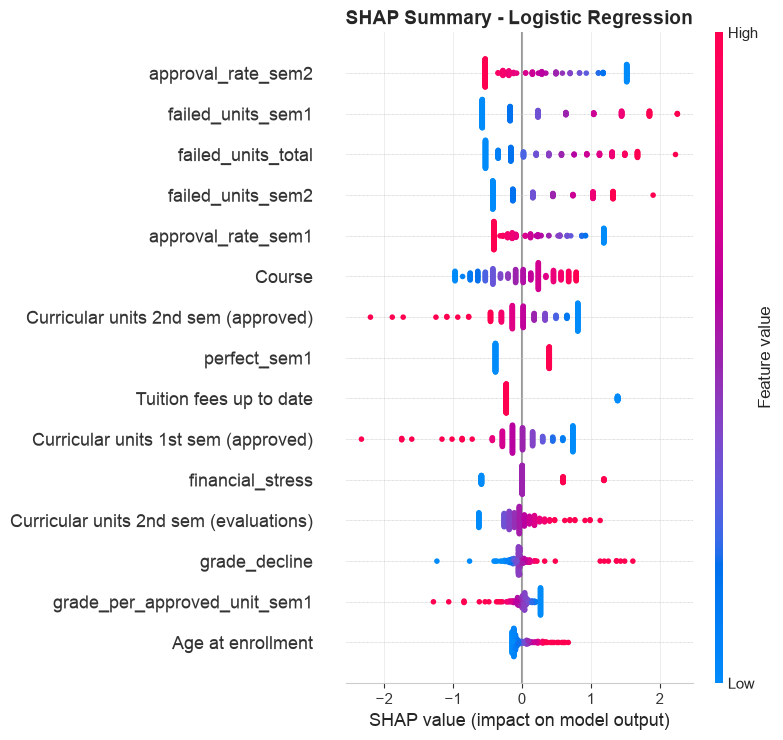

In [192]:
lr_shap_subset = subset_shap(lr_shap_values, top_20_features, X_test.columns)
X_sample_subset = X_sample_scaled_df[top_20_features]

fig, ax = plt.subplots(figsize=(10.0, 8.0))
shap.summary_plot(
    lr_shap_subset,
    X_sample_subset,
    feature_names=top_20_features,
    max_display=15,
    show=False
)
plt.title('SHAP Summary - Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary_lr.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Bar Plot - mean absolute SHAP values

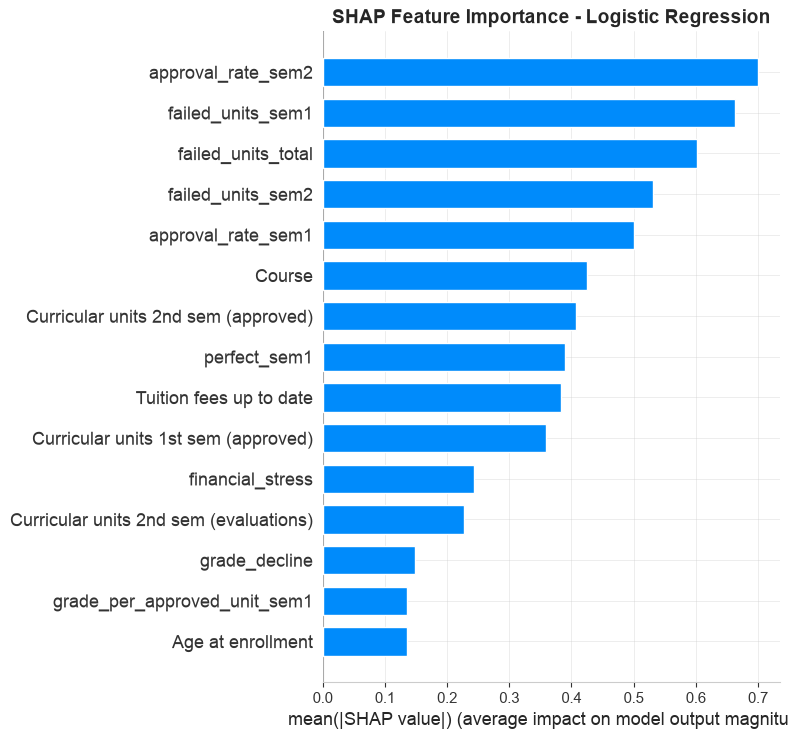

In [193]:
fig, ax = plt.subplots(figsize=(10.0, 6.0))
shap.summary_plot(
    lr_shap_subset,
    X_sample_subset,
    feature_names=top_20_features,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance - Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_bar_lr.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Waterfall Plot - explain a single prediction

--- Single Prediction Explanation (Logistic Regression) ---
Sample 0:
  Actual: Graduate
  Predicted probability: 1.4%


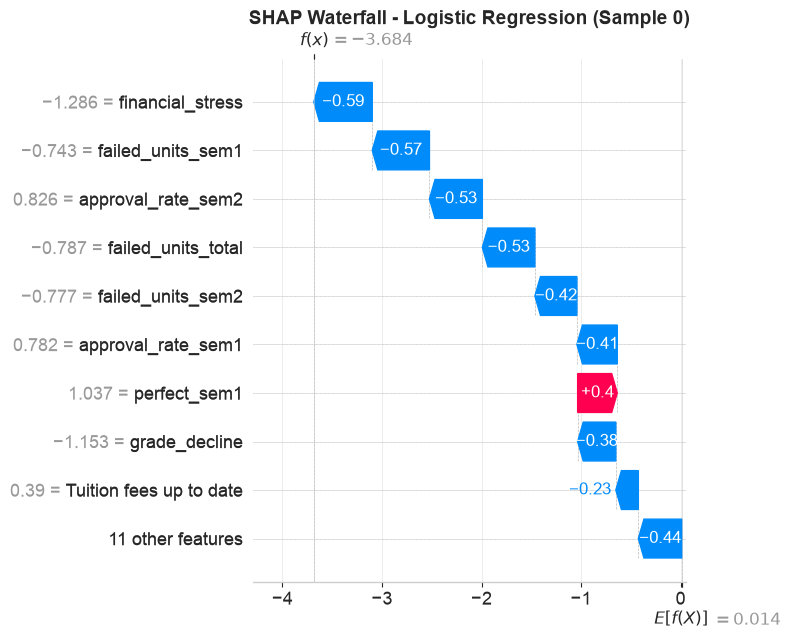

In [194]:
print("--- Single Prediction Explanation (Logistic Regression) ---")

sample_idx = 0
actual = y_test[sample_idx]
predicted_proba = lr_model.predict_proba(X_test_scaled[sample_idx:sample_idx+1])[0, 1]

print(f"Sample {sample_idx}:")
print(f"  Actual: {'Dropout' if actual == 1 else 'Graduate'}")
print(f"  Predicted probability: {predicted_proba:.1%}")

fig, ax = plt.subplots(figsize=(10.0, 6.0))
shap.waterfall_plot(
    shap.Explanation(
        values=lr_shap_subset[sample_idx],
        base_values=lr_explainer.expected_value,
        data=X_sample_subset.iloc[sample_idx].values,
        feature_names=top_20_features
    ),
    max_display=10,
    show=False
)
plt.title(f'SHAP Waterfall - Logistic Regression (Sample {sample_idx})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_lr.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Force Plot - stacked SHAP values for multiple samples

In [195]:
print("--- Force Plot (First 20 samples) ---")

feature_indices = [list(X_test.columns).index(f) for f in top_20_features]
lr_shap_subset = lr_shap_values[:20, :][:, feature_indices]
X_display = X_sample_scaled_df[top_20_features].iloc[:20]

# Generate the force plot and save as HTML
force_plot = shap.force_plot(
    lr_explainer.expected_value,
    lr_shap_subset,
    X_display,
    feature_names=top_20_features
)

# Save to HTML file
shap.save_html('../reports/figures/shap_force_lr.html', force_plot)
print("Force plot saved to ../reports/figures/shap_force_lr.html")
print("   Open this file in a web browser to view the interactive plot.")

--- Force Plot (First 20 samples) ---
Force plot saved to ../reports/figures/shap_force_lr.html
   Open this file in a web browser to view the interactive plot.


### Logistic Regression - Built-in Coefficients

Since LR is inherently interpretable, we can also use its coefficients directly.

In [196]:
# Direct coefficient interpretation
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])

print("Top 10 Risk Factors (positive coefficients):")
print("-" * 65)
for _, row in coef_df.head(10).iterrows():
    print(f"    {row['Feature']:<40s} | Coef: {row['Coefficient']:+.4f} | Odds: {row['Odds_Ratio']:.2f}x")
print()

print("Top 10 Protective Factors (negative coefficients):")
print("-" * 65)
for _, row in coef_df.tail(10).iterrows():
    print(f"    {row['Feature']:<40s} | Coef: {row['Coefficient']:+.4f} | Odds: {row['Odds_Ratio']:.2f}x")

Top 10 Risk Factors (positive coefficients):
-----------------------------------------------------------------
    failed_units_sem1                        | Coef: +0.8233 | Odds: 2.28x
    failed_units_total                       | Coef: +0.7572 | Odds: 2.13x
    evaluation_intensity_sem1                | Coef: +0.7258 | Odds: 2.07x
    failed_units_sem2                        | Coef: +0.6479 | Odds: 1.91x
    Curricular units 1st sem (credited)      | Coef: +0.5653 | Odds: 1.76x
    Course                                   | Coef: +0.4836 | Odds: 1.62x
    disengagement_sem1                       | Coef: +0.4738 | Odds: 1.61x
    financial_stress                         | Coef: +0.4486 | Odds: 1.57x
    International                            | Coef: +0.4108 | Odds: 1.51x
    perfect_sem1                             | Coef: +0.3901 | Odds: 1.48x

Top 10 Protective Factors (negative coefficients):
-----------------------------------------------------------------
    Curricular units 

Visualize

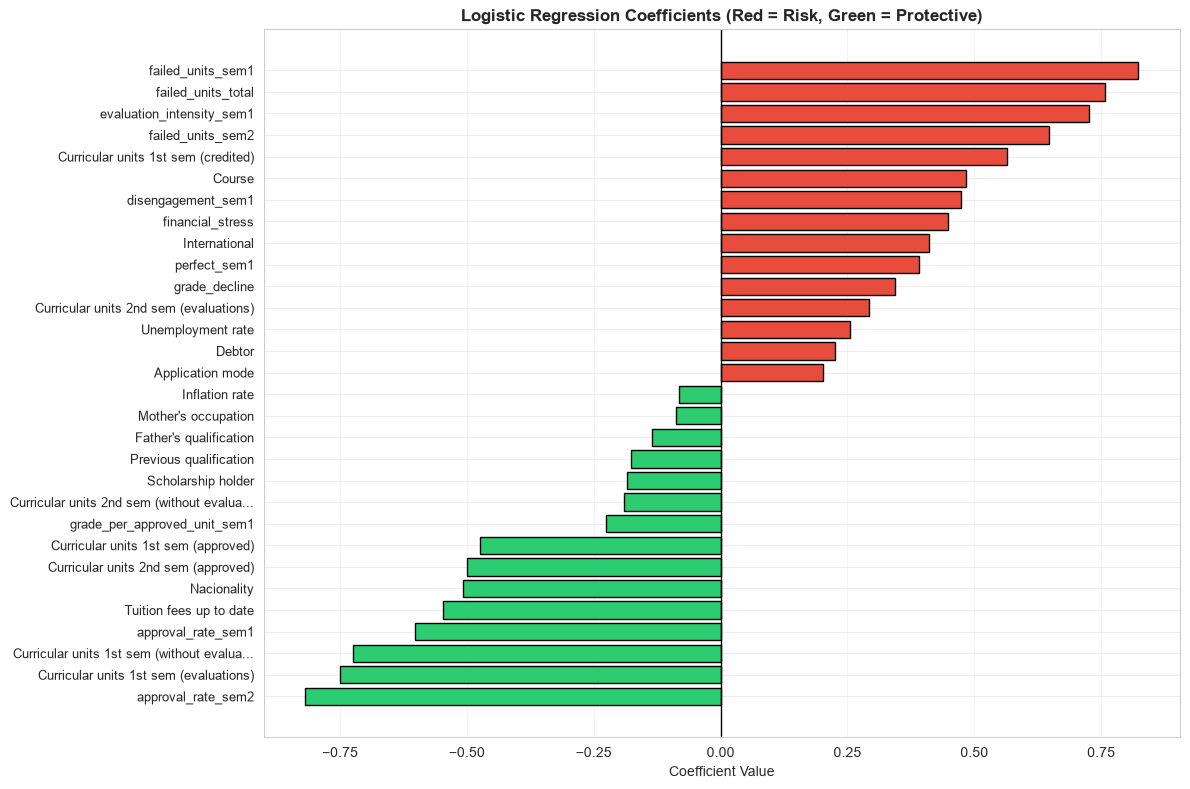

In [197]:
fig, ax = plt.subplots(figsize=(12.0, 8.0))
top_30 = coef_df.head(15).copy()
bottom_15 = coef_df.tail(15).copy()
plot_coefs = pd.concat([top_30, bottom_15]).drop_duplicates()
plot_coefs = plot_coefs.sort_values('Coefficient')

colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in plot_coefs['Coefficient']]
ax.barh(range(len(plot_coefs)), plot_coefs['Coefficient'].values, color=colors, edgecolor='black')
ax.set_yticks(range(len(plot_coefs)))
ax.set_yticklabels([f[:40] + '...' if len(f) > 43 else f for f in plot_coefs['Feature']], fontsize=9)
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression Coefficients (Red = Risk, Green = Protective)', fontweight='bold')
ax.axvline(x=0, color='black', linewidth=1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Random Forest - SHAP Analysis

In [198]:
print("=" * 70)
print("RANDOM FOREST - SHAP ANALYSIS")
print("=" * 70)

# TreeExplainer for Random Forest
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values_raw = rf_explainer.shap_values(X_sample)

# Handle SHAP output: shape (200, 51, 2) -> take class 1
print(f"Raw SHAP type: {type(rf_shap_values_raw)}")
print(f"    Array shape: {rf_shap_values_raw.shape}")

# Take SHAP values for class 1 (Dropout = positive class)
rf_shap_values = rf_shap_values_raw[:, :, 1]
print(f"Final SHAP values shape: {rf_shap_values.shape}")

# Get expected value for class 1
if isinstance(rf_explainer.expected_value, np.ndarray):
    base_value = float(rf_explainer.expected_value[1])
else:
    base_value = float(rf_explainer.expected_value)
print(f"Base value (expected): {base_value:.4f}")

RANDOM FOREST - SHAP ANALYSIS
Raw SHAP type: <class 'numpy.ndarray'>
    Array shape: (200, 51, 2)
Final SHAP values shape: (200, 51)
Base value (expected): 0.4989


### 5.1 Summary Plot

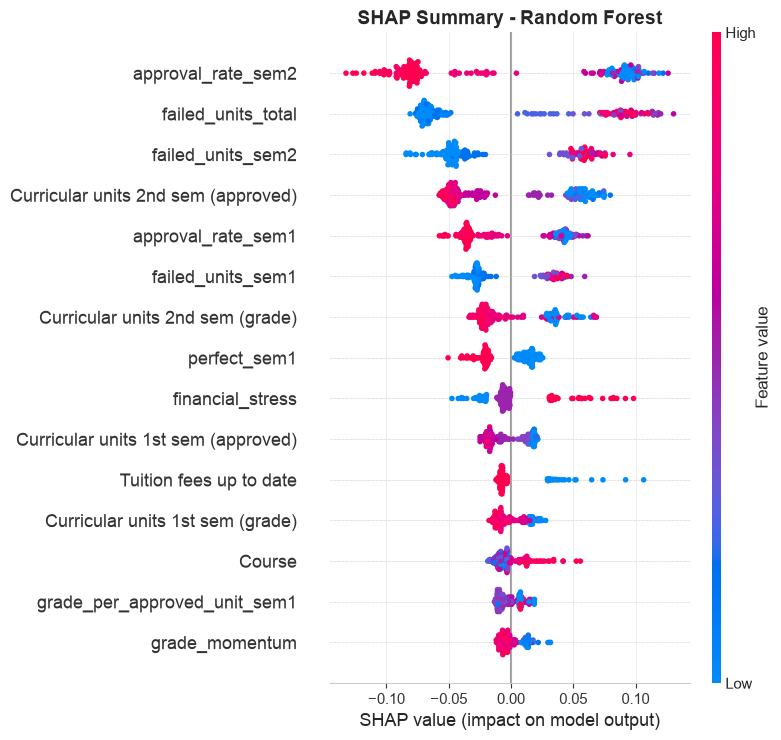

In [199]:
rf_shap_subset = subset_shap(rf_shap_values, top_20_features, X_test.columns)
X_sample_rf_subset = X_sample[top_20_features]

fig, ax = plt.subplots(figsize=(10.0, 8.0))
shap.summary_plot(
    rf_shap_subset,
    X_sample_rf_subset,
    feature_names=top_20_features,
    max_display=15,
    show=False
)
plt.title('SHAP Summary - Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary_rf.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Bar Plot

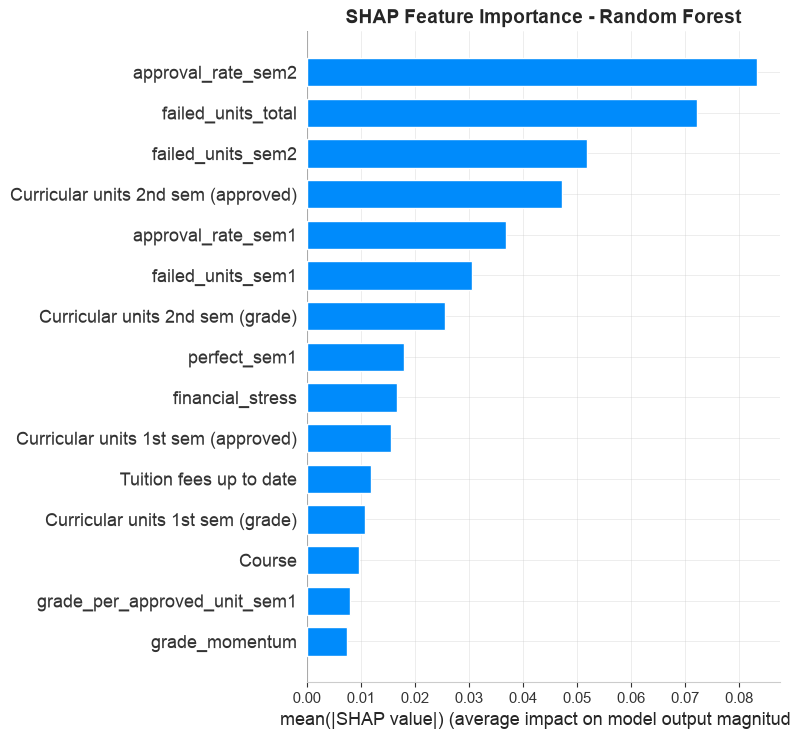

In [200]:
fig, ax = plt.subplots(figsize=(10.0, 6.0))
shap.summary_plot(
    rf_shap_subset,
    X_sample_rf_subset,
    feature_names=top_20_features,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_bar_rf.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Waterfall Plot

--- Single Prediction Explanation (Random Forest) ---
Sample 0:
    Actual: Graduate
    Predicted probability: 11.9%
Single sample SHAP shape: (20,)
Base value: 0.4989
Type: <class 'float'>


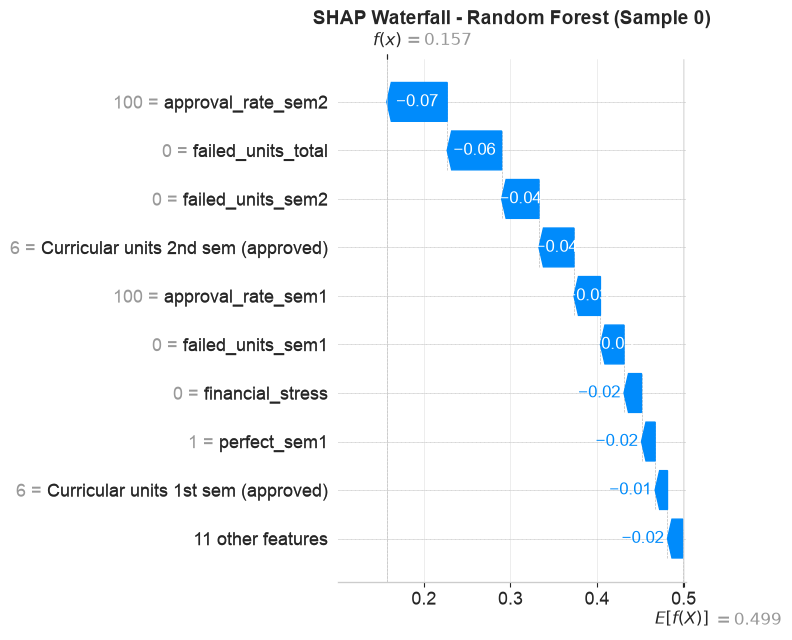

In [201]:
print("--- Single Prediction Explanation (Random Forest) ---")

sample_idx = 0
actual = y_test[sample_idx]
predicted_proba = rf_model.predict_proba(X_test.iloc[sample_idx:sample_idx+1])[0, 1]

print(f"Sample {sample_idx}:")
print(f"    Actual: {'Dropout' if actual == 1 else 'Graduate'}")
print(f"    Predicted probability: {predicted_proba:.1%}")

# Get single sample SHAP values (shape: (20,))
single_shap = rf_shap_subset[sample_idx]
print(f"Single sample SHAP shape: {single_shap.shape}")

# Ensure base_value is a Python float, not a numpy array
base_value = float(rf_explainer.expected_value[1]) if isinstance(rf_explainer.expected_value, np.ndarray) else float(rf_explainer.expected_value)
print(f"Base value: {base_value:.4f}")
print(f"Type: {type(base_value)}")

fig, ax = plt.subplots(figsize=(10.0, 6.0))
shap.waterfall_plot(
    shap.Explanation(
        values=single_shap,
        base_values=base_value,
        data=X_sample_rf_subset.iloc[sample_idx].values,
        feature_names=top_20_features
    ),
    max_display=10,
    show=False
)
plt.title(f'SHAP Waterfall - Random Forest (Sample {sample_idx})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_rf.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Dependence Plots

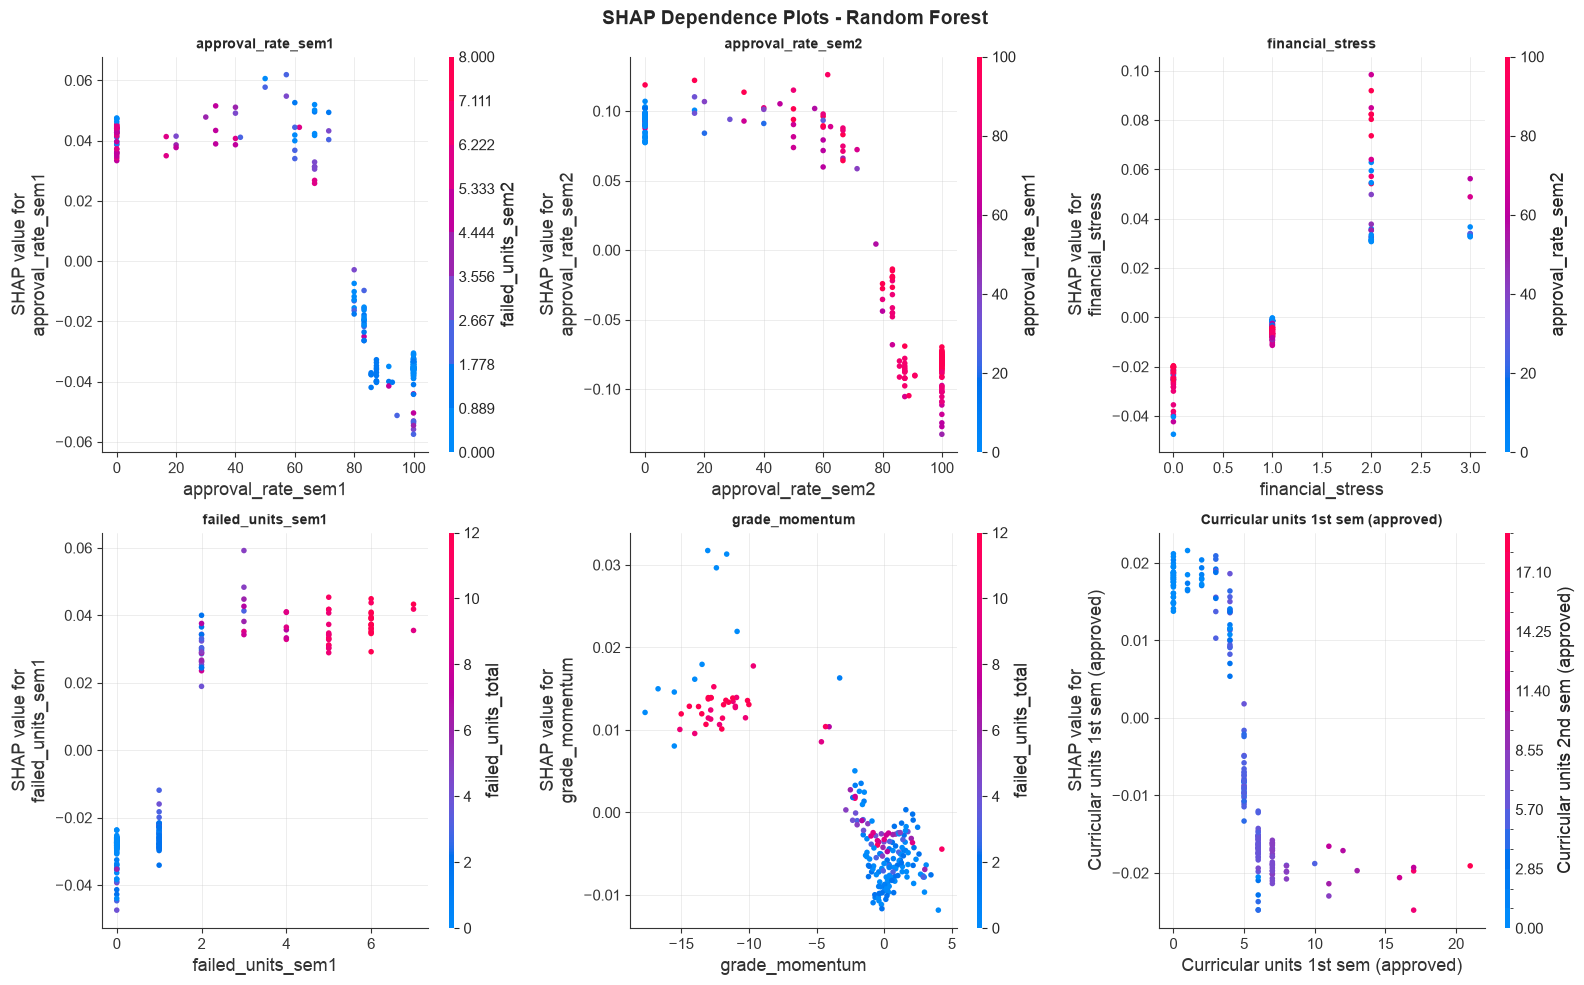

In [202]:
fig, axes = plt.subplots(2, 3, figsize=(16.0, 10.0))
axes = axes.flatten()

key_features = [
    'approval_rate_sem1', 'approval_rate_sem2',
    'financial_stress', 'failed_units_sem1',
    'grade_momentum', 'Curricular units 1st sem (approved)'
]

for i, feat in enumerate(key_features):
    if feat in top_20_features and i < len(axes):
        ax = axes[i]
        feat_idx = top_20_features.index(feat)
        shap.dependence_plot(
            feat_idx, rf_shap_subset, X_sample_rf_subset,
            feature_names=top_20_features,
            ax=ax, show=False
        )
        ax.set_title(feat, fontweight='bold', fontsize=10)

# Hide unused subplots
for i in range(len(key_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('SHAP Dependence Plots - Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_dependence_rf.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Random Forest

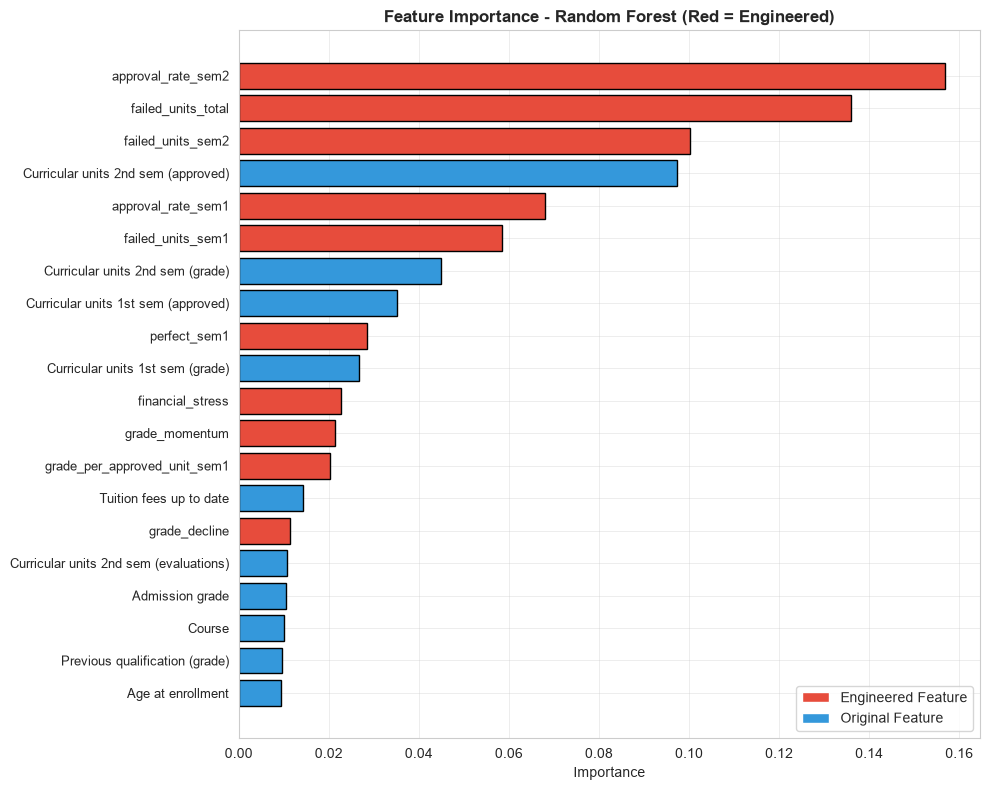

In [203]:
# Built-in feature importance (faster, but less detailed than SHAP)
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10.0, 8.0))
top_features = rf_importance.head(20)

# Color engineered features differently
engineered = ['approval_rate_sem1', 'approval_rate_sem2', 'grade_momentum', 
              'grade_decline', 'financial_stress', 'perfect_sem1',
              'disengagement_sem1', 'parent_education', 'evaluation_intensity_sem1',
              'credit_utilization_sem1', 'total_course_load', 
              'failed_units_sem1', 'failed_units_sem2', 'failed_units_total',
              'grade_per_approved_unit_sem1']

colors = ['#e74c3c' if f in engineered else '#3498db' for f in top_features['Feature']]
ax.barh(range(len(top_features)), top_features['Importance'].values, color=colors, edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels([f[:45] + '...' if len(f) > 48 else f for f in top_features['Feature']], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('Feature Importance - Random Forest (Red = Engineered)', fontweight='bold')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Engineered Feature'),
    Patch(facecolor='#3498db', label='Original Feature')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. XGBoost - SHAP Analysis

In [204]:
print("=" * 70)
print("XGBOOST - SHAP ANALYSIS")
print("=" * 70)

# TreeExplainer for XGBoost
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_sample)

print(f"SHAP values shape: {xgb_shap_values.shape}")

XGBOOST - SHAP ANALYSIS
SHAP values shape: (200, 51)


### 6.1 Summary Plot

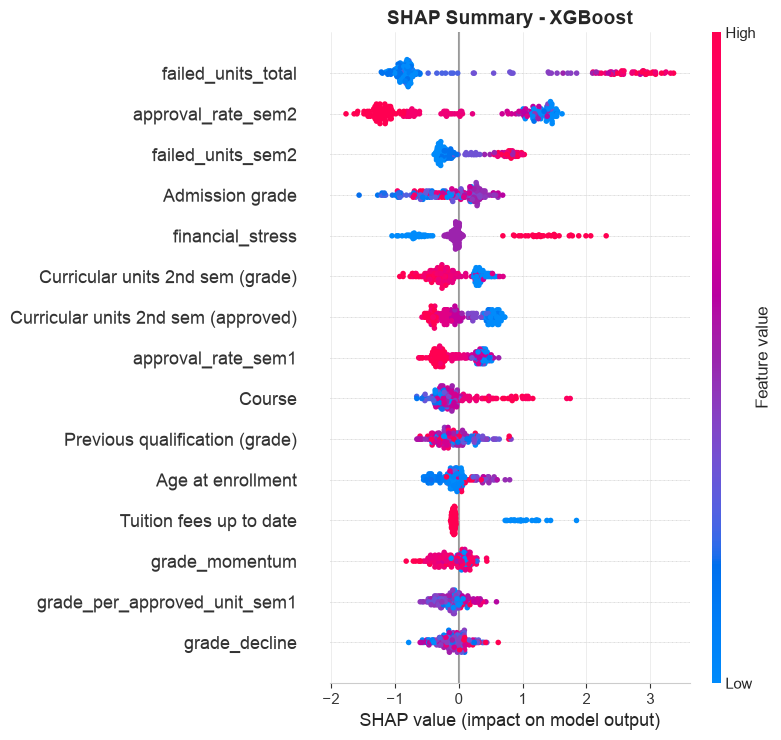

In [205]:
xgb_shap_subset = subset_shap(xgb_shap_values, top_20_features, X_test.columns)
X_sample_xgb_subset = X_sample[top_20_features]

fig, ax = plt.subplots(figsize=(10.0, 8.0))
shap.summary_plot(
    xgb_shap_subset,
    X_sample_xgb_subset,
    feature_names=top_20_features,
    max_display=15,
    show=False
)
plt.title('SHAP Summary - XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Bar Plot

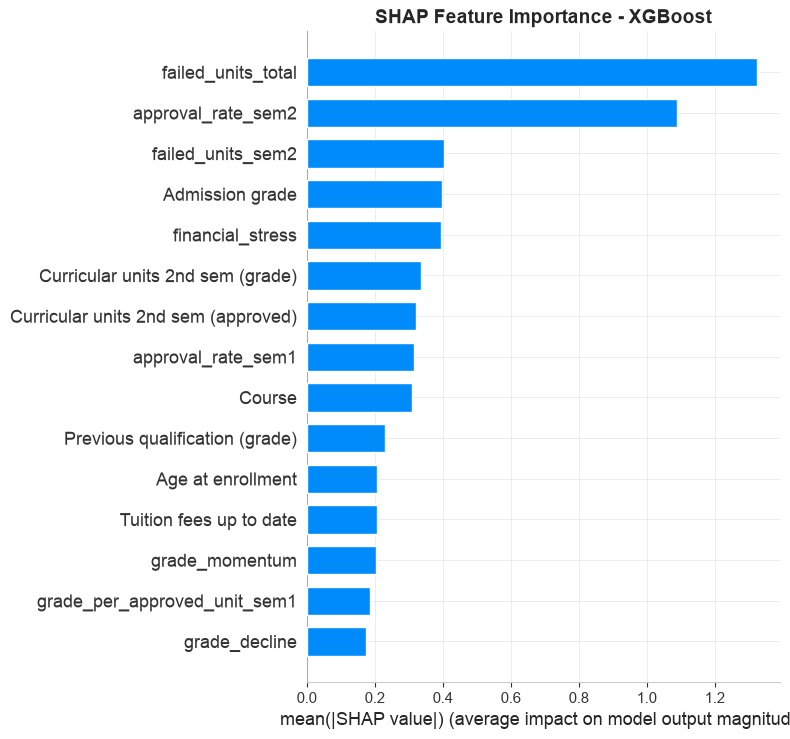

In [206]:
fig, ax = plt.subplots(figsize=(10.0, 6.0))
shap.summary_plot(
    xgb_shap_subset,
    X_sample_xgb_subset,
    feature_names=top_20_features,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance - XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_bar_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Waterfall Plot

In [207]:
print("--- Single Prediction Explanation (XGBoost) ---")

sample_idx = 0
actual = y_test[sample_idx]
predicted_proba = xgb_model.predict_proba(X_test.iloc[sample_idx:sample_idx+1])[0, 1]

print(f"Sample {sample_idx}:")
print(f"    Actual: {'Dropout' if actual == 1 else 'Graduate'}")
print(f"    Predicted probability: {predicted_proba:.1%}")

--- Single Prediction Explanation (XGBoost) ---
Sample 0:
    Actual: Graduate
    Predicted probability: 0.4%


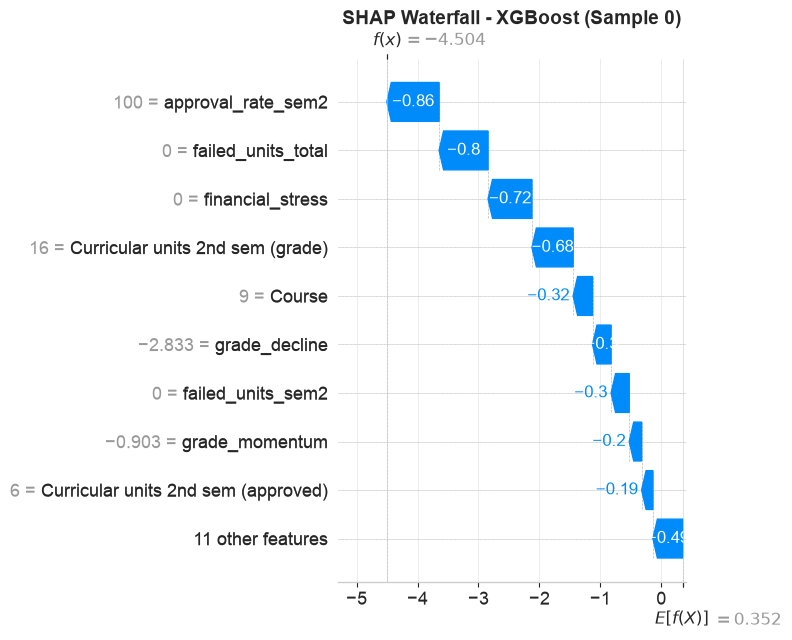

In [208]:
fig, ax = plt.subplots(figsize=(10.0, 6.0))
shap.waterfall_plot(
    shap.Explanation(
        values=xgb_shap_subset[sample_idx],
        base_values=xgb_explainer.expected_value,
        data=X_sample_xgb_subset.iloc[sample_idx].values,
        feature_names=top_20_features
    ),
    max_display=10,
    show=False
)
plt.title(f'SHAP Waterfall - XGBoost (Sample {sample_idx})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Comparison - SHAP Values

MODEL COMPARISON - SHAP FEATURE IMPORTANCE


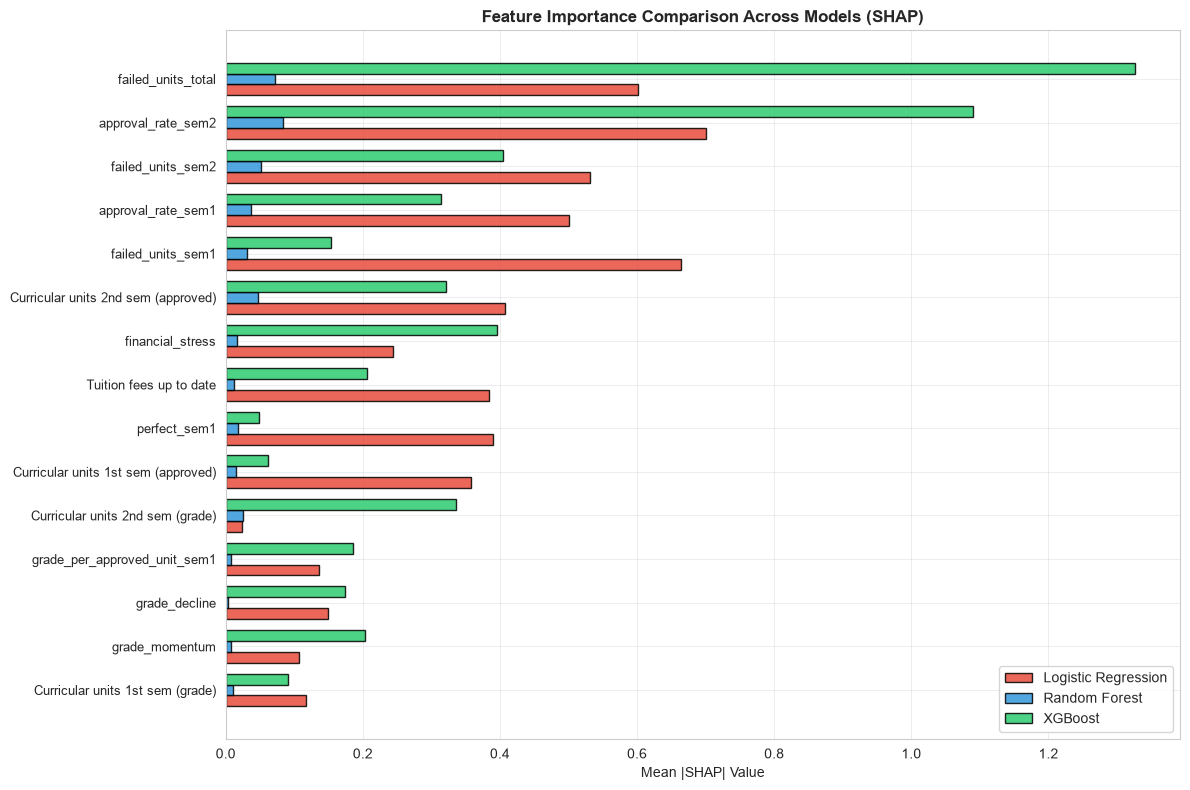

In [209]:
print("=" * 70)
print("MODEL COMPARISON - SHAP FEATURE IMPORTANCE")
print("=" * 70)

# Calculate mean absolute SHAP values for each model
lr_importance = np.abs(lr_shap_values).mean(axis=0)
rf_importance_shap = np.abs(rf_shap_values).mean(axis=0)
xgb_importance_shap = np.abs(xgb_shap_values).mean(axis=0)

# Create comparison DataFrame (using top features from RF)
comparison_features = top_20_features[:15]

comparison_data = []
for feat in comparison_features:
    idx = list(X_sample.columns).index(feat)
    comparison_data.append({
        'Feature': feat,
        'Logistic Regression': lr_importance[idx],
        'Random Forest': rf_importance_shap[idx],
        'XGBoost': xgb_importance_shap[idx]
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Mean'] = comparison_df[['Logistic Regression', 'Random Forest', 'XGBoost']].mean(axis=1)
comparison_df = comparison_df.sort_values('Mean', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12.0, 8.0))
x = np.arange(len(comparison_df))
width = 0.25

ax.barh(x - width, comparison_df['Logistic Regression'], width, 
        label='Logistic Regression', color='#e74c3c', alpha=0.85, edgecolor='black')
ax.barh(x, comparison_df['Random Forest'], width, 
        label='Random Forest', color='#3498db', alpha=0.85, edgecolor='black')
ax.barh(x + width, comparison_df['XGBoost'], width, 
        label='XGBoost', color='#2ecc71', alpha=0.85, edgecolor='black')

ax.set_yticks(x)
ax.set_yticklabels([f[:35] + '...' if len(f) > 38 else f for f in comparison_df['Feature']], fontsize=9)
ax.set_xlabel('Mean |SHAP| Value')
ax.set_title('Feature Importance Comparison Across Models (SHAP)', fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/shap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Decision Tree Visualization

In [210]:
print("=" * 70)
print("DECISION TREE VISUALIZATION")
print("=" * 70)

# Train a simpler decision tree for visualization
dt_viz = DecisionTreeClassifier(
    max_depth=3,           # Shallow tree for readability
    min_samples_leaf=30,   # Minimum samples per leaf
    class_weight='balanced',
    random_state=42
)
dt_viz.fit(X_train, y_train)

print(f"Decision Tree trained:")
print(f"    Depth: {dt_viz.get_depth()}")
print(f"    Leaves: {dt_viz.get_n_leaves()}")
print(f"    Test ROC-AUC: {roc_auc_score(y_test, dt_viz.predict_proba(X_test)[:, 1]):.4f}")

DECISION TREE VISUALIZATION
Decision Tree trained:
    Depth: 3
    Leaves: 7
    Test ROC-AUC: 0.9557


Visualize the tree

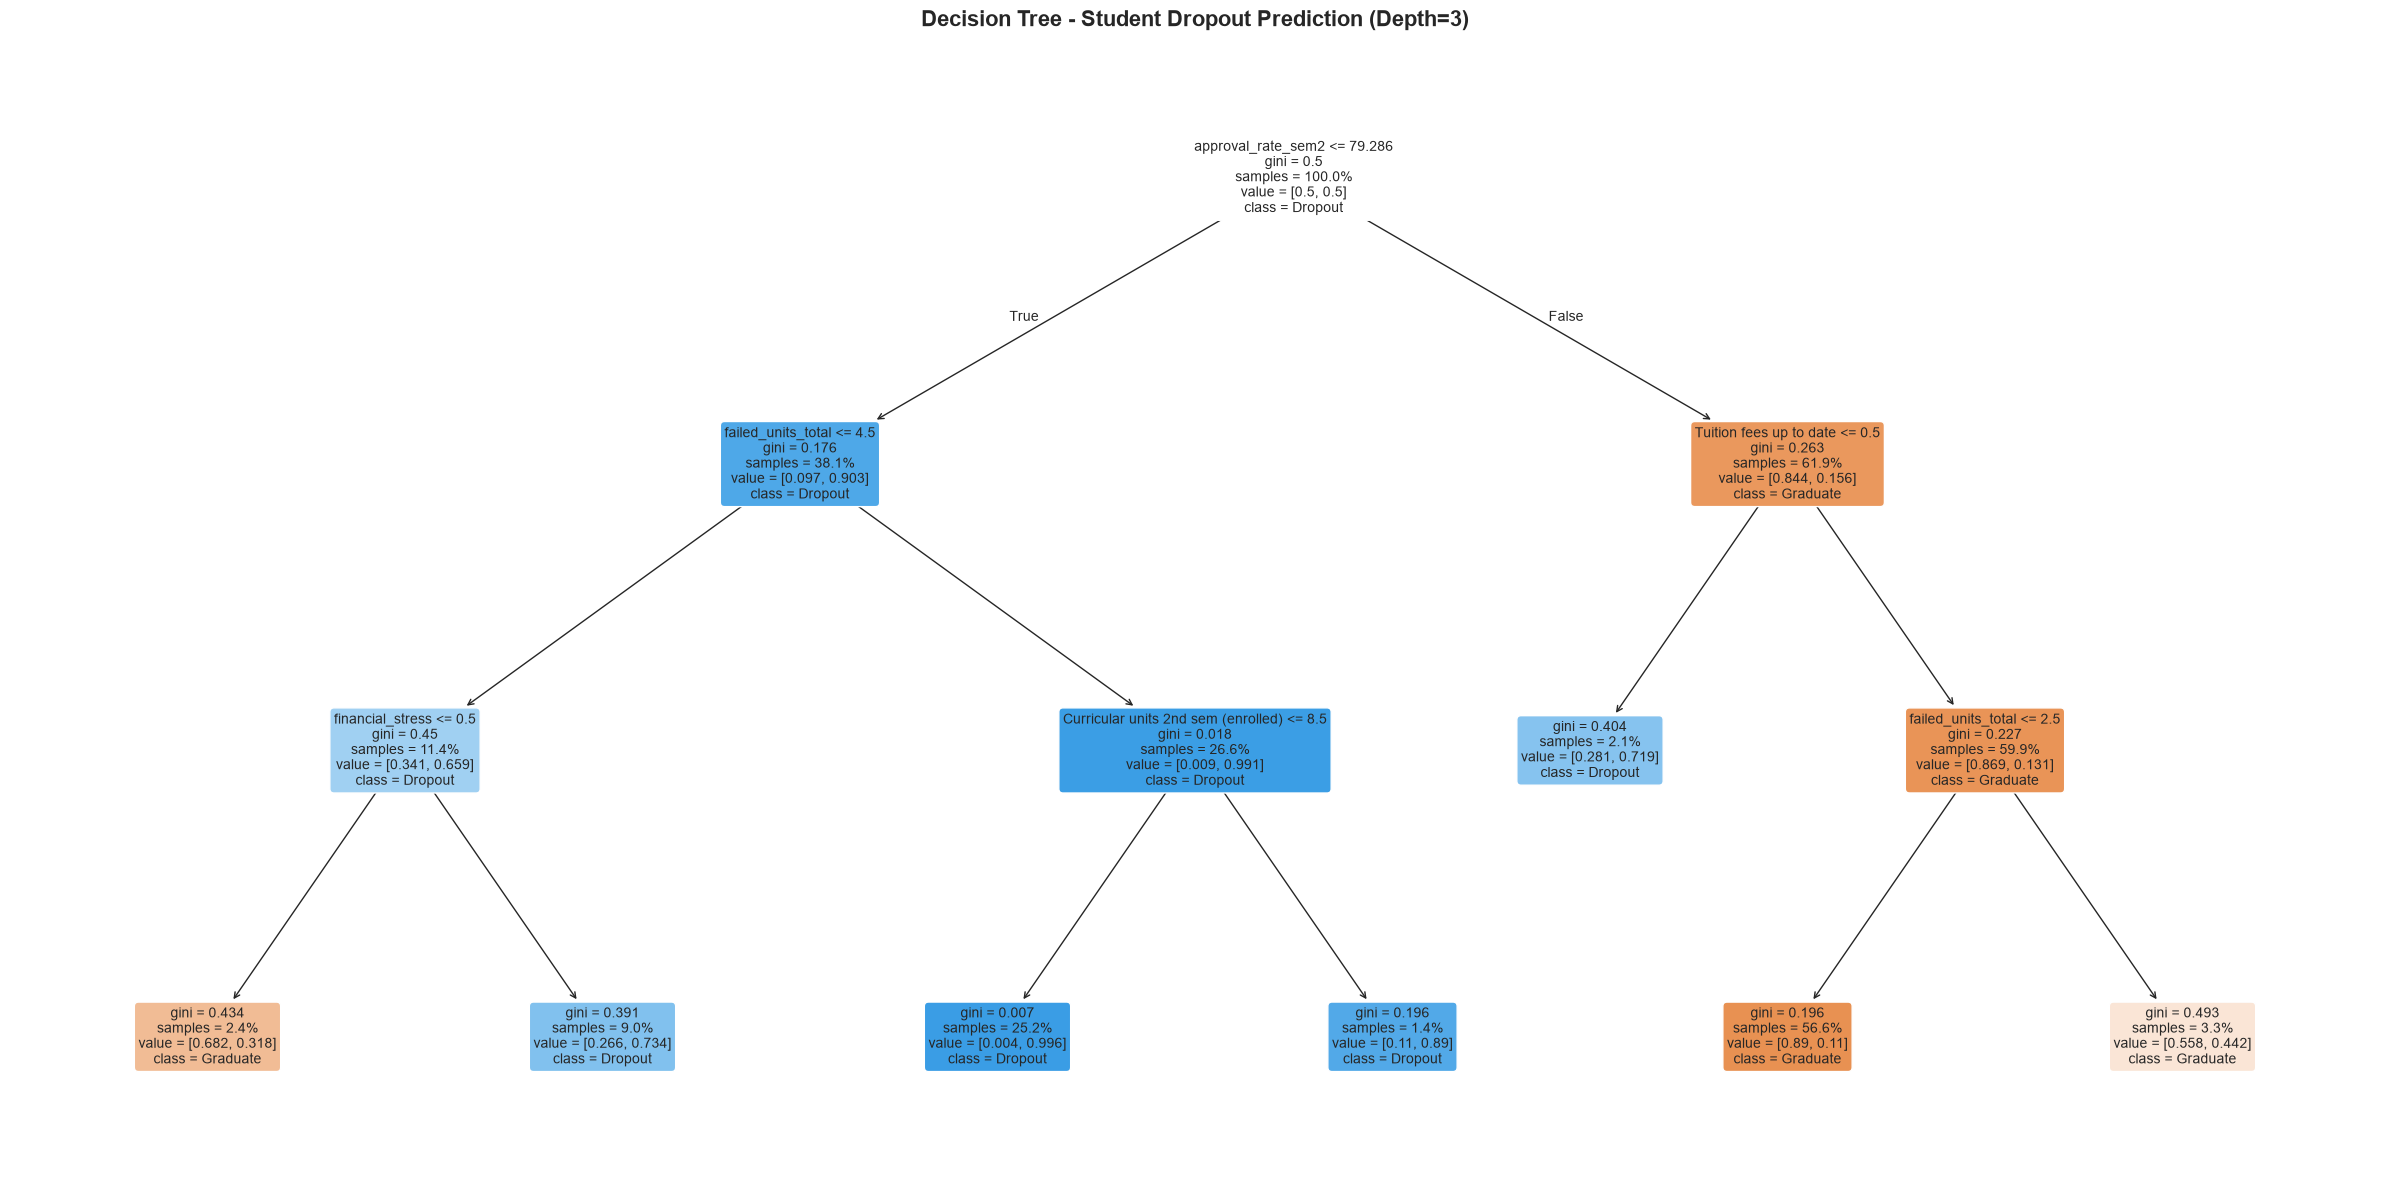

In [211]:
fig, ax = plt.subplots(figsize=(24.0, 12.0))
plot_tree(
    dt_viz,
    feature_names=X_train.columns.tolist(),
    class_names=['Graduate', 'Dropout'],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True,
    impurity=True,
    ax=ax
)
plt.title('Decision Tree - Student Dropout Prediction (Depth=3)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

Text representation

In [212]:
print("--- Decision Rules (Text) ---")
tree_rules = export_text(
    dt_viz,
    feature_names=X_train.columns.tolist(),
    max_depth=3
)
print(tree_rules)

--- Decision Rules (Text) ---
|--- approval_rate_sem2 <= 79.29
|   |--- failed_units_total <= 4.50
|   |   |--- financial_stress <= 0.50
|   |   |   |--- class: 0
|   |   |--- financial_stress >  0.50
|   |   |   |--- class: 1
|   |--- failed_units_total >  4.50
|   |   |--- Curricular units 2nd sem (enrolled) <= 8.50
|   |   |   |--- class: 1
|   |   |--- Curricular units 2nd sem (enrolled) >  8.50
|   |   |   |--- class: 1
|--- approval_rate_sem2 >  79.29
|   |--- Tuition fees up to date <= 0.50
|   |   |--- class: 1
|   |--- Tuition fees up to date >  0.50
|   |   |--- failed_units_total <= 2.50
|   |   |   |--- class: 0
|   |   |--- failed_units_total >  2.50
|   |   |   |--- class: 0



## 9. Partial Dependence Plots

PARTIAL DEPENDENCE PLOTS
PDP features to plot: ['approval_rate_sem1', 'approval_rate_sem2', 'financial_stress', 'failed_units_sem1', 'grade_momentum', 'Curricular units 1st sem (approved)']
Training data shape: (2178, 51)


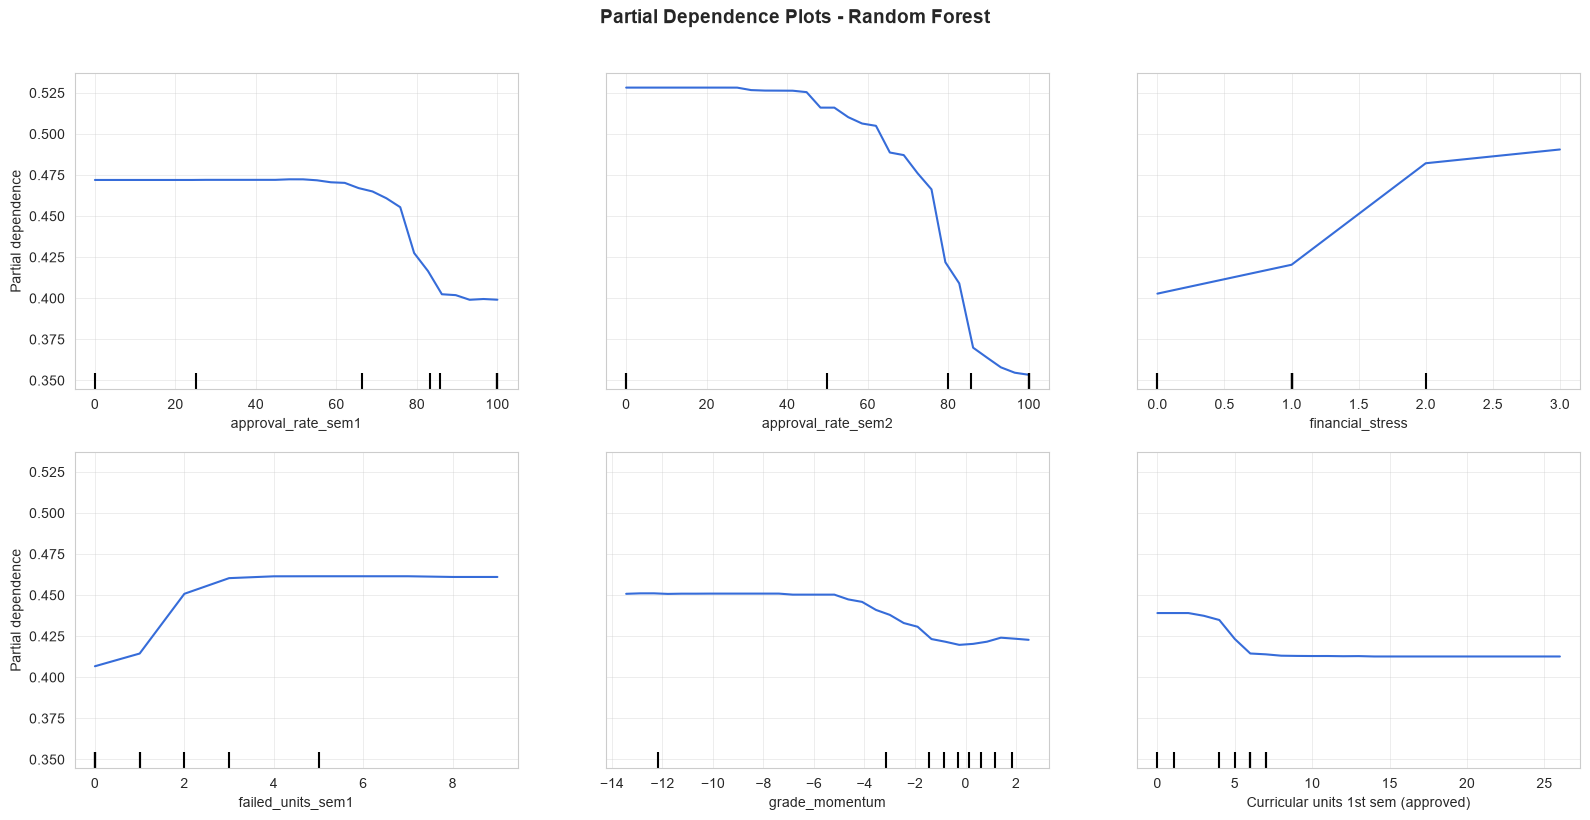

In [213]:
print("=" * 70)
print("PARTIAL DEPENDENCE PLOTS")
print("=" * 70)

# Key features to analyze
pdp_features = [
    'approval_rate_sem1',
    'approval_rate_sem2',
    'financial_stress',
    'failed_units_sem1',
    'grade_momentum',
    'Curricular units 1st sem (approved)'
]

# Filter to existing features
pdp_features = [f for f in pdp_features if f in X_train.columns]

# Use the FULL training data (all features), converted to float
X_train_float = X_train.astype(float)

print(f"PDP features to plot: {pdp_features}")
print(f"Training data shape: {X_train_float.shape}")

fig, ax = plt.subplots(figsize=(16.0, 8.0))

PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train_float,            # FULL feature set (all 51 columns)
    pdp_features,             # Features to plot (6 columns)
    grid_resolution=30,
    ax=ax
)

plt.suptitle('Partial Dependence Plots - Random Forest', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Individual Conditional Expectation (ICE) Plots

ICE PLOTS - INDIVIDUAL PREDICTIONS


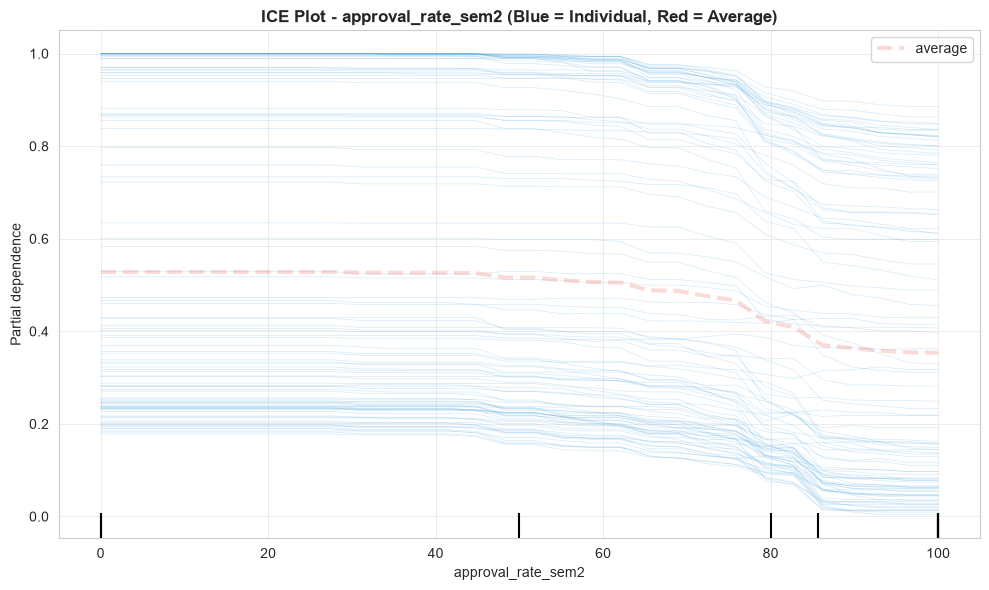

In [214]:
print("=" * 70)
print("ICE PLOTS - INDIVIDUAL PREDICTIONS")
print("=" * 70)

# Use FULL training data, converted to float
X_train_float = X_train.astype(float)

fig, ax = plt.subplots(figsize=(10.0, 6.0))

PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train_float,             # FULL feature set (all 51 columns)
    ['approval_rate_sem2'],    # Single feature to plot
    kind='both',
    subsample=100,
    grid_resolution=30,
    ax=ax,
    line_kw={'color': '#3498db', 'alpha': 0.2},
    pd_line_kw={'color': '#e74c3c', 'linewidth': 3}
)

plt.title('ICE Plot - approval_rate_sem2 (Blue = Individual, Red = Average)', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/ice_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save SHAP Values for Future Use

In [215]:
# Save SHAP values and explainers
shap_dir = Path('../models/shap')
shap_dir.mkdir(parents=True, exist_ok=True)

# Save SHAP values as numpy arrays
np.save(shap_dir / 'lr_shap_values.npy', lr_shap_values)
np.save(shap_dir / 'rf_shap_values.npy', rf_shap_values)
np.save(shap_dir / 'xgb_shap_values.npy', xgb_shap_values)

# Save explainers
joblib.dump(lr_explainer, shap_dir / 'lr_explainer.pkl')
joblib.dump(rf_explainer, shap_dir / 'rf_explainer.pkl')
joblib.dump(xgb_explainer, shap_dir / 'xgb_explainer.pkl')

print("SHAP values and explainers saved to models/shap/")

print()
print("=" * 70)
print("MODEL INTERPRETATION COMPLETE")
print("=" * 70)
print(f"""
Generated explanations for:
    - Logistic Regression (coefficients + SHAP)
    - Random Forest (feature importance + SHAP)
    - XGBoost (SHAP)

Key files saved:
    - reports/figures/shap_summary_*.png
    - reports/figures/shap_waterfall_*.png
    - reports/figures/decision_tree.png
    - reports/figures/partial_dependence.png
    - models/shap/*.npy, *.pkl
""")

SHAP values and explainers saved to models/shap/

MODEL INTERPRETATION COMPLETE

Generated explanations for:
    - Logistic Regression (coefficients + SHAP)
    - Random Forest (feature importance + SHAP)
    - XGBoost (SHAP)

Key files saved:
    - reports/figures/shap_summary_*.png
    - reports/figures/shap_waterfall_*.png
    - reports/figures/decision_tree.png
    - reports/figures/partial_dependence.png
    - models/shap/*.npy, *.pkl

